In [1]:
print("Hello world ")

Hello world 


In [ ]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
plt.style.use("default")
sns.set(font_scale=1.1)#select front size by using this  


1.Setup and data loading

we discuss about heart .csv data file and work on it

In [5]:
#import csv file 
df=pd.read_csv('heart.csv')
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [6]:
#Basic info about rows, columns, and data types
print('shape :', df.shape)

shape : (918, 12)


In [ ]:
print("Info :",df.info())#kono null nei ai database a 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB
Info : None


In [12]:
#Quick descriptive statistics for numeric column
df.describe().T#transpose this output matrix using T 

,count,mean,std,min,25%,50%,75%,max
Age,918.0,53.510893,9.432617,28.0,47.00,54.0,60.0,77.0
RestingBP,918.0,132.396514,18.514154,0.0,120.00,130.0,140.0,200.0
Cholesterol,918.0,198.799564,109.384145,0.0,173.25,223.0,267.0,603.0
FastingBS,918.0,0.233115,0.423046,0.0,0.00,0.0,0.0,1.0
MaxHR,918.0,136.809368,25.460334,60.0,120.00,138.0,156.0,202.0
Oldpeak,918.0,0.887364,1.066570,-2.6,0.00,0.6,1.5,6.2
HeartDisease,918.0,0.553377,0.497414,0.0,0.00,1.0,1.0,1.0


In [13]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'Oldpeak', 'ST_Slope',
       'HeartDisease'],
      dtype='object')

In [18]:
#define  target and Feature types
target_col='HeartDisease'
numeric_col=['Age','RestingBP','Cholesterol','FastingBS','MaxHR','Oldpeak']

catagorical_Col=['Sex',"ChestPainType","RestingECG","ExerciseAngina"]
print(target_col)
print(numeric_col)
print(catagorical_Col)

HeartDisease
['Age', 'RestingBP', 'Cholesterol', 'FastingBS', 'MaxHR', 'Oldpeak']
['Sex', 'ChestPainType', 'RestingECG', 'ExerciseAngina']


MISSING VALUES AND BASIC  QUALITY CHECKS 

In [ ]:
#check missing value 
df.isna().sum()#there is no missing value 

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [21]:
#Look at some basic value ranges 
df[numeric_col].agg(['min','max','mean','median']).T

,min,max,mean,median
Age,28.0,77.0,53.510893,54.0
RestingBP,0.0,200.0,132.396514,130.0
Cholesterol,0.0,603.0,198.799564,223.0
FastingBS,0.0,1.0,0.233115,0.0
MaxHR,60.0,202.0,136.809368,138.0
Oldpeak,-2.6,6.2,0.887364,0.6


In [ ]:
for c in catagorical_Col:
    print(c,df[c].unique())
    #data input deoyar somoy a onk a hoyto bhul korte pare catagorical data 
    # hoyto male, female lekhar somoy sapace diye dise jeta bhul jinish 
    #tai  amader unuque ness thik rakte hobe data distribution ar khetre unique 
    #khuje ber korte hobe amader value gula 

    #m,M,FeMale,male,M, ai bhabe thake pare 
    # onno rokom thakle aikhan a dekha jete  sex a catagorical  value 2 ar jaigay onk gula 

Sex ['M' 'F']
ChestPainType ['ATA' 'NAP' 'ASY' 'TA']
RestingECG ['Normal' 'ST' 'LVH']
ExerciseAngina ['N' 'Y']


HISTROGRAM FOR NUMERICAL FEATURE 

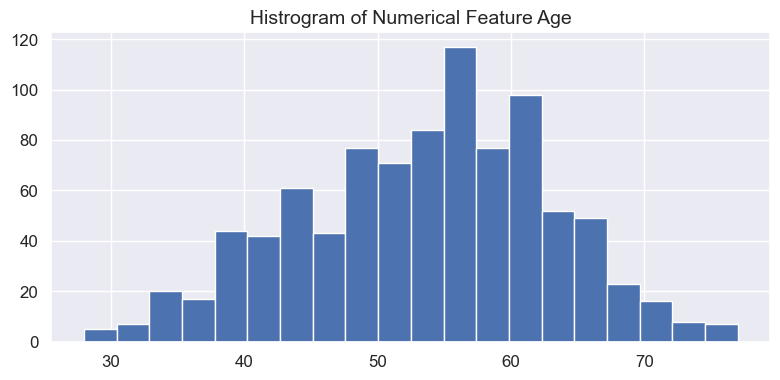

In [ ]:
df['Age'].hist(bins=20,figsize=(8,4))
plt.title("Histrogram of Numerical Feature Age",fontsize=14)
plt.tight_layout()
plt.show()#motamoti distributed data 

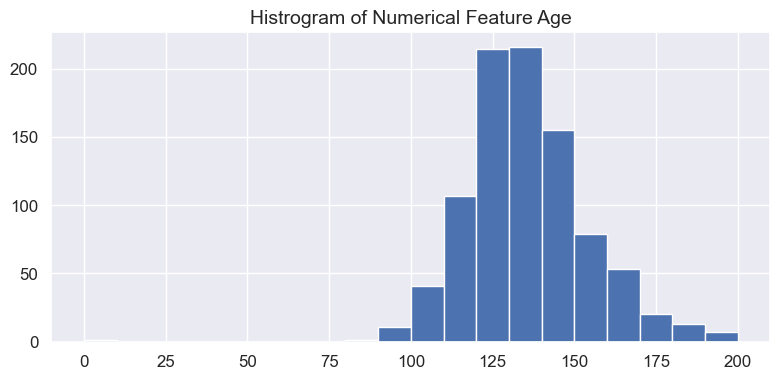

In [28]:
#numerical data visulazation
df['RestingBP'].hist(bins=20,figsize=(8,4))
plt.title("Histrogram of Numerical Feature Age",fontsize=14)
plt.tight_layout()
plt.show()#motamoti distributed data 

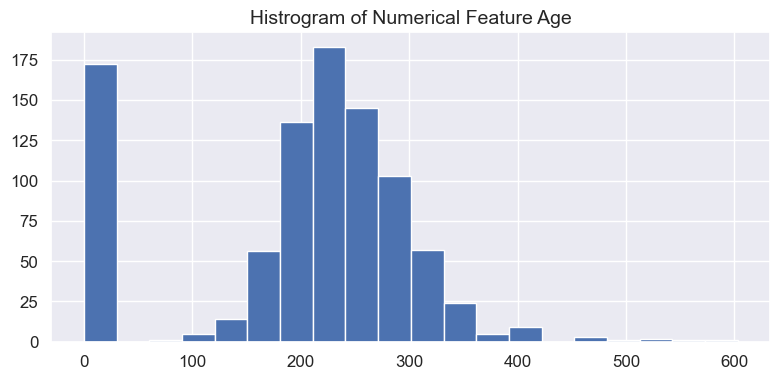

In [ ]:
df['Cholesterol'].hist(bins=20,figsize=(8,4))
plt.title("Histrogram of Numerical Feature Age",fontsize=14)
plt.tight_layout()
plt.show()#there is a outliar in this data set cholestrol is not 0 
# there is a outliar

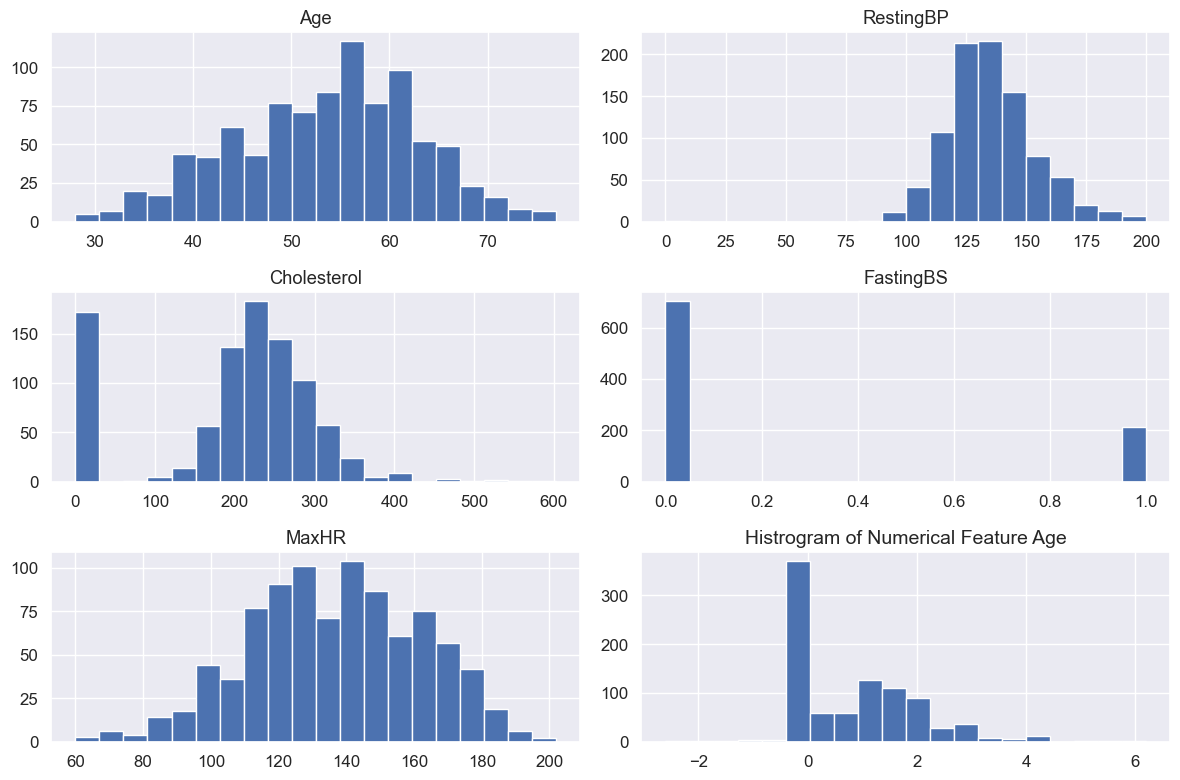

In [ ]:
#sob gula numerical feature ar  histrogram dekboo amra ak sathe 
df[numeric_col].hist(bins=20,figsize=(12,8))
plt.title("Histrogram of Numerical Feature Age",fontsize=14)
plt.tight_layout()
plt.show() 

#SEE boxplot to detect outliar in this numeric_column s

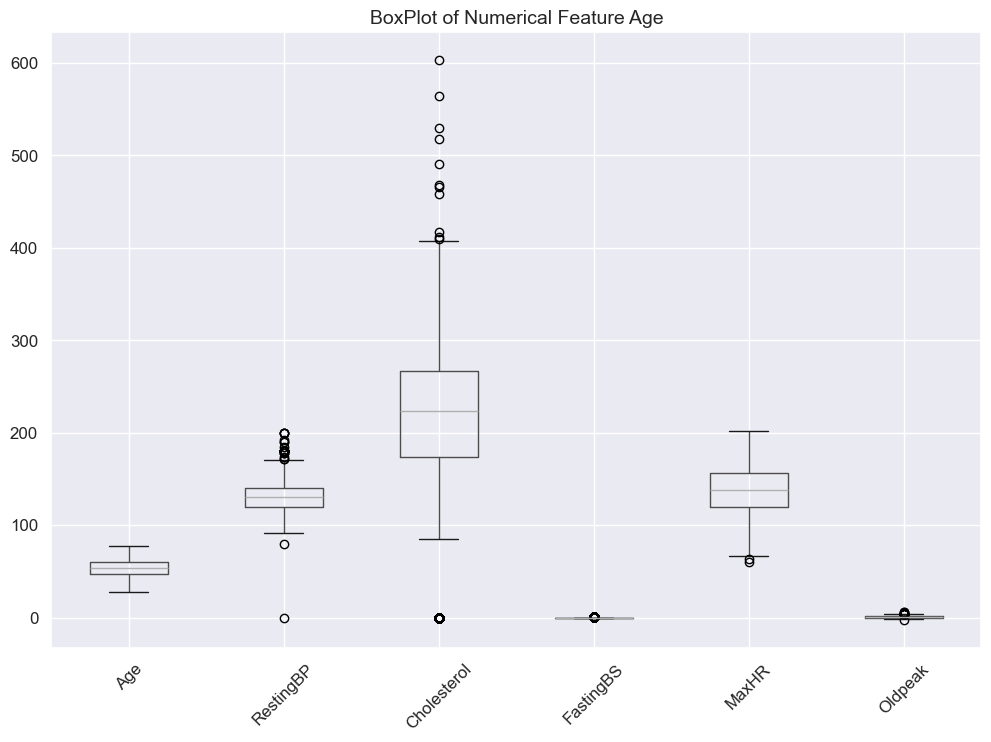

In [35]:
plt.figure(figsize=(12,8))
df[numeric_col].boxplot()
plt.title("BoxPlot of Numerical Feature Age",fontsize=14)
plt.xticks(rotation=45)
plt.show() 

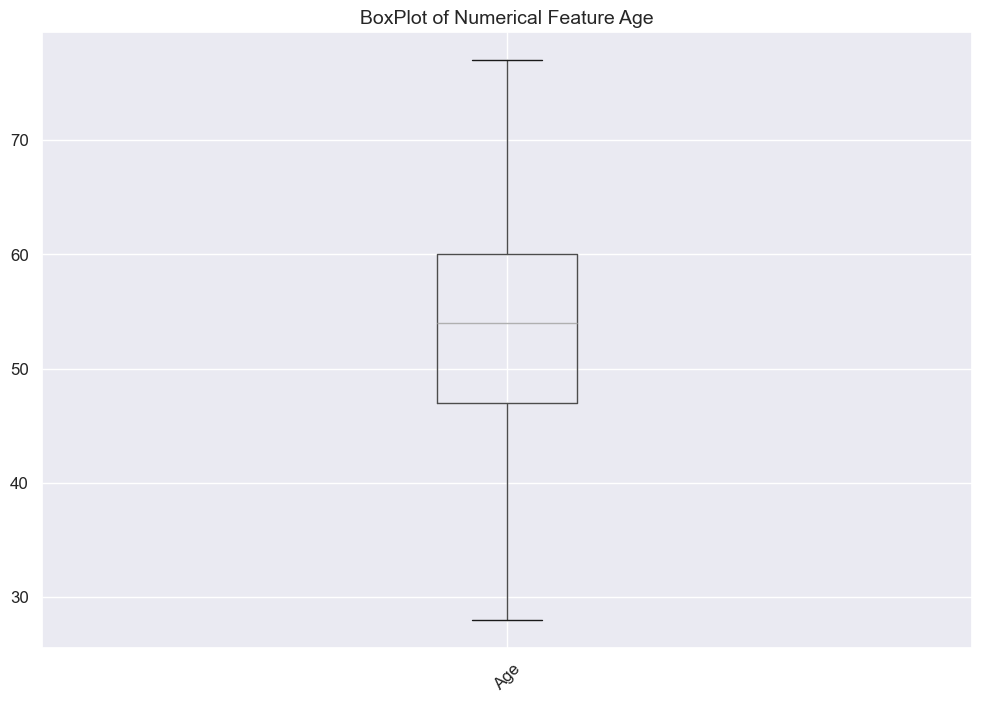

In [ ]:
plt.figure(figsize=(12,8))
df.boxplot(column=numeric_col[0])
plt.title("BoxPlot of Numerical Feature Age",fontsize=14)
plt.xticks(rotation=45)
plt.show() #box ar bahirer point gula outliar hobe  

Target Distribution and class imbalance

In [39]:
df.head(10)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0
5,39,M,NAP,120,339,0,Normal,170,N,0.0,Up,0
6,45,F,ATA,130,237,0,Normal,170,N,0.0,Up,0
7,54,M,ATA,110,208,0,Normal,142,N,0.0,Up,0
8,37,M,ASY,140,207,0,Normal,130,Y,1.5,Flat,1
9,48,F,ATA,120,284,0,Normal,120,N,0.0,Up,0


In [40]:
df[numeric_col]

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak
0,40,140,289,0,172,0.0
1,49,160,180,0,156,1.0
2,37,130,283,0,98,0.0
3,48,138,214,0,108,1.5
4,54,150,195,0,122,0.0
...,...,...,...,...,...,...
913,45,110,264,0,132,1.2
914,68,144,193,1,141,3.4
915,57,130,131,0,115,1.2
916,57,130,236,0,174,0.0


In [41]:
df[catagorical_Col].head(5)

,Sex,ChestPainType,RestingECG,ExerciseAngina
0,M,ATA,Normal,N
1,F,NAP,Normal,N
2,M,ATA,ST,N
3,F,ASY,Normal,Y
4,M,NAP,Normal,N


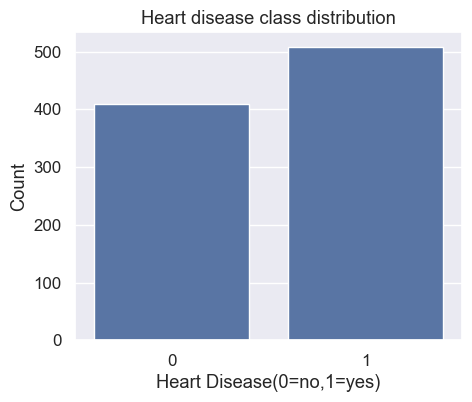

In [38]:
#Target value niye kaj korbo
plt.figure(figsize=(5,4))
sns.countplot(x=df[target_col])
plt.title("Heart disease class distribution")
plt.xlabel("Heart Disease(0=no,1=yes)")
plt.ylabel("Count")
plt.show()


In [43]:
#percentage wise dekbo konta koto percent heartdisease
df[target_col].value_counts(normalize=True)

HeartDisease
1    0.553377
0    0.446623
Name: proportion, dtype: float64

CATEGORICAL FEATURE EXPLORATION

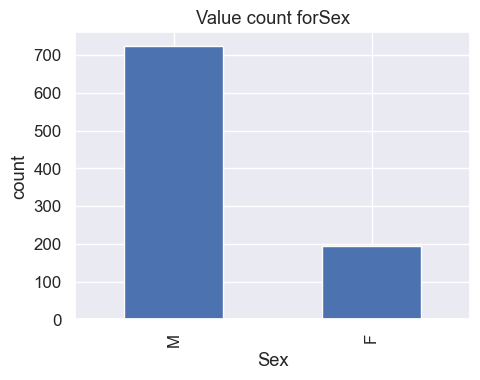

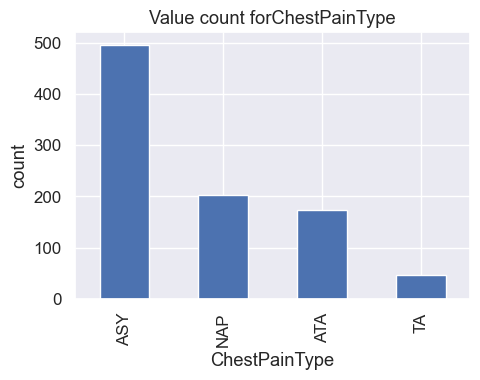

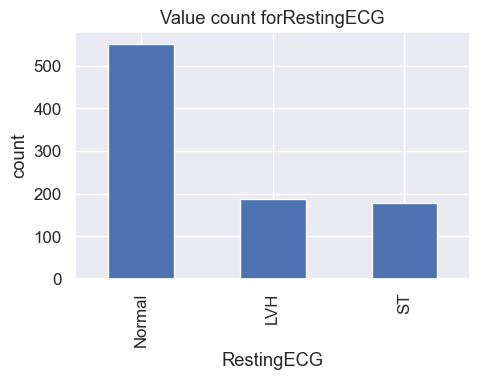

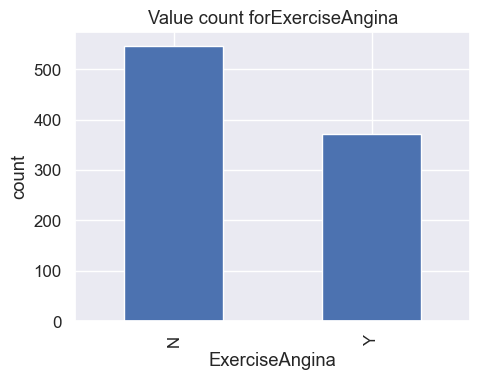

In [48]:
#viwe all categorical feature s
for c in catagorical_Col:
    plt.figure(figsize=(5,4))
    df[c].value_counts().plot(kind="bar")
    plt.title(f"Value count for{c}")
    plt.ylabel("count")

    plt.tight_layout()
    plt.show()